In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque


In [55]:
GRID_SIZE = 5
ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)
OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]

GAMMA = 0.9
EPSILON = 0.05
num_episodes = 2000
num_steps = 1000
state_dim = 25
action_dim = len(ACTION)
batch_size = 32
capacity = 10000
target_update_freq = 10
obstacle_through = True

In [36]:

def extract_features(state, action_idx, FEATURE_DIM, ACTION):
    """
    状态动作特征提取函数
    将 状态、动作对 转化为长度为 125 的 One-hot 编码特征向量
    输入: state (r, c), action_idx
    输出: feature_vector (长度为 FEATURE_DIM 的 numpy 数组)
    """
    x = np.zeros(FEATURE_DIM)
    r, c = state

    # 每一行有 GRID_SIZE*len(ACTION) = 25 个元素
    # 每一个格子有 len(ACTION) = 5 个元素
    idx = r * (GRID_SIZE * len(ACTION)) + c * len(ACTION) + action_idx

    x[idx] = 1.0
    return x

def get_q_value(state, action_idx, FEATURE_DIM, ACTION, w):
    """
    计算线性函数逼近的 Q 值: q_hat = w^T * x
    """
    x = extract_features(state, action_idx, FEATURE_DIM, ACTION)
    return np.dot(w, x)

def get_epsilon_greedy_action(q_values, EPSILON, ACTION):
    """
    epsilon-greedy 策略选择动作
    """
    if np.random.rand() < EPSILON:
        return np.random.randint(len(ACTION)) # 随机选择动作
    else:
        # 为了防止多个动作 Q 值一样大（比如初始全是 0），用 np.random.choice 随机挑一个最大的动作
        max_q = np.argmax(q_values) # 找到最大的 Q 值
        best_actions = np.where(q_values == q_values[max_q])[0]
        return np.random.choice(best_actions)
    




In [37]:
"""
提取訓練好的 DQN 神經網絡中的 Q 值，還原成一個 (GRID_SIZE, GRID_SIZE, action_dim) 的 Q 表
"""
def extract_q_table_from_net(trained_net, env, grid_size, action_dim):
    """
    将训练好的 DQN 神经网络，还原成 (GRID_SIZE, GRID_SIZE, action_dim) 的 3D Q 表
    """
    # 1. 准备一个全 0 的空白 Q 表
    Q_table = np.zeros((grid_size, grid_size, action_dim))
    
    # 2. 将网络切换到评估模式 (锁定参数)
    trained_net.eval() 
    
    # 3. 暴力遍历地图上的每一个坐标
    for r in range(grid_size):
        for c in range(grid_size):
            state = (r, c)
            
            state_vec = env._get_state_vector(state)
            
            # 转换成 PyTorch 需要的 Tensor 格式 (别忘了升维变成 Batch Size = 1)
            state_tensor = torch.FloatTensor(state_vec).unsqueeze(0)
            
            # 让大脑进行推演，算出这个坐标下 5 个动作的 Q 值
            with torch.no_grad():
                # .squeeze() 是把 (1, 5) 降维回 (5,)
                # .numpy() 是把 PyTorch Tensor 变回 NumPy 数组
                q_values = trained_net(state_tensor).squeeze().numpy()
                
            # 把这 5 个打分填入我们准备好的 Q 表对应位置
            Q_table[r, c] = q_values
            
    return Q_table

"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=True):
    final_policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    final_V = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if (i, j) in OBSTACLE and not obstacle_through:
                continue 
            
            # 提取最大 Q 值对应的动作 (argmax)
            final_policy[i, j] = np.argmax(Q_final[i, j])
            # 提取最大 Q 值作为该格子的状态价值 V(s) (max)
            final_V[i, j] = np.max(Q_final[i, j])
    
    return final_policy, final_V

In [38]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, Epsilon, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(f"Control ($\gamma$={GAMMA}, $\epsilon$={Epsilon}) | Obstacle Through: {obstacle_through}")
    plt.show()


def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

In [49]:
"""
环境
"""
class GridEnv:
    def __init__(self, GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=False):
        self.GRID_SIZE = GRID_SIZE
        self.GOAL_STATE = GOAL_STATE
        self.OBSTACLE = OBSTACLE
        self.ACTION = ACTION
        self.obstacle_through = obstacle_through

        self.state_dim = GRID_SIZE * GRID_SIZE
        self.current_state = None
    
    def _get_state_vector(self, state):
        """
        内部辅助函数：将二维坐标 (r, c) 转换为长度为 25 的 One-hot 一维向量
        因为 PyTorch 的神经网络需要浮点型的数组作为输入
        """
        vec = np.zeros(self.state_dim)
        r, c = state
        idx = r * self.GRID_SIZE + c
        vec[idx] = 1.0
        return vec
    
    def reset(self):
        """
        episode 重置：随机生成一个合法的起点，并返回其状态向量
        """
        while True:
            r = np.random.randint(self.GRID_SIZE)
            c = np.random.randint(self.GRID_SIZE)
            state = (r, c)
            if state == self.GOAL_STATE:
                continue
            if not self.obstacle_through and state in self.OBSTACLE:
                continue
            break

        self.current_state = state
        return self._get_state_vector(self.current_state)
    
    def step(self, action_idx):
        """
        执行动作：返回 next_state(向量形式), reward, done(是否结束)
        """
        r, c = self.current_state
        dr, dc = self.ACTION[action_idx]
        next_r, next_c = r + dr, c + dc

        done = False

        # 边界检查
        if next_r < 0 or next_r >= self.GRID_SIZE or next_c < 0 or next_c >= self.GRID_SIZE:
            reward = -1.0
            next_state = self.current_state
        
        else:
            next_state = (next_r, next_c)
            if self.obstacle_through and next_state in self.OBSTACLE:
                reward = -10.0

            elif not self.obstacle_through and next_state in self.OBSTACLE:
                reward = -10.0
                next_state = self.current_state
            
            elif next_state == self.GOAL_STATE:
                reward = 1.0
                done = True  # 到达终点，episode 结束
            
            else:
                reward = -0.1 # 每一步的惩罚，鼓励智能体尽快找到目标
        
        self.current_state = next_state

        return self._get_state_vector(self.current_state), reward, done


In [50]:
"""
DQN Q神经网络, 代替线性函数的Q

"""
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        # 网络结构为简单的三层全连接层网络，输入为状态维度，输出为动作维度的Q值
        self.fc1 = nn.Linear(state_dim, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, action_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x) # 输出各个动作的Q值


"""
定义经验回放池 (Replay Buffer) 用于存储智能体的经验数据
"""
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity) # 使用双端队列，满了之后会自动把最旧的数据丢弃
    
    def push(self, state, action, reward, next_state, done):
        # 将一步的经验存入记忆池
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        # 从记忆池里随机采样一个批次的经验数据
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch)) # 解压批次数据并转换为numpy数组, 方便后续转换为PyTorch张量
        # 以 state为例，它是一个二维数组，形状为 (batch_size, state_dim)，每一行是一个状态的向量表示
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)
    

In [51]:
"""
DQN算法
"""

def train_dqn(env, num_episodes, num_steps, state_dim, action_dim, batch_size, GAMMA, EPSILON, target_update_freq, capacity=10000, obstacle_through=False):

    env.obstacle_through = obstacle_through
    
    # 实例化 mian Q network 和 target Q network
    main_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)

    # 同步初始化权重
    target_net.load_state_dict(main_net.state_dict())
    target_net.eval() # target net 不需要训练

    optimizer = optim.Adam(main_net.parameters(), lr=0.001)
    memory = ReplayBuffer(capacity=capacity)

    steps_done = 0
    return_history = []

    for ep in range(num_episodes):
        state = env.reset()
        episode_total_reward = 0.0

        # 每个 episode 最多 num_steps 步，防止死循环
        for t in range(num_steps):
            # 身体：ε-greedy 策略选择动作，收集经验数据
            if random.random() < EPSILON:
                action = random.randint(0, action_dim - 1)
            else:
                # 转为 PyTorch 的 FloatTensor，并添加一个 batch 维度 (1, state_dim)，以符合神经网络所期望的输入形式：批次形式
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                with torch.no_grad():
                    q_values = main_net(state_tensor) # 前向传播得到各个动作的 Q 值，输出是一个形状为 (1, action_dim) 的张量
                    action = q_values.argmax().item() # 选择 Q 值最大的动作，得到一个标量动作索引

            next_state, reward, done = env.step(action)
            episode_total_reward += reward

            memory.push(state, action, reward, next_state, done)


            # 大脑：从经验回放池中采样，更新 main net
            if len(memory) >= batch_size:
                b_states, b_actions, b_rewards, b_next_states, b_dones = memory.sample(batch_size)

                # 转换为 PyTorch 张量
                # b_state, b_next_state 是二维数组，形状为 (batch_size, state_dim)，每一行是一个状态的向量表示
                # b_action, b_reward, b_done 是一维数组，形状为 (batch_size,)，每个元素分别是一个动作索引、奖励值和是否结束的标志, 需要转换为适合神经网络输入的张量形式
                b_states = torch.FloatTensor(b_states)
                b_actions = torch.LongTensor(b_actions).unsqueeze(1)
                b_rewards = torch.FloatTensor(b_rewards).unsqueeze(1)
                b_next_states = torch.FloatTensor(b_next_states)
                b_dones = torch.FloatTensor(b_dones).unsqueeze(1)

                # 计算当前 Q 值
                # main_net\target_net(b_states) 的输出是一个形状为 (batch_size, action_dim) 的张量，表示每个状态下各个动作的 Q 值
                # 根据b_actions里面存储的aciton idx，然后对维度action_dim进行某个维度的选择性保留(可以是多种维度的结合)，得到一个形状为 (batch_size, 1) 的张量，表示每个状态下所选择动作的 Q 值
                current_q = main_net(b_states).gather(1, b_actions) # 预测值 q_hat(S, A, w) 选择对应动作的 Q 值

                # 计算目标 Q 值
                with torch.no_grad():
                    # 从 target net 的输出中选择下一个状态的最大 Q 值，作为目标 Q 值的一部分
                    #  target_net 前向传播后得到 (batch_size, action_dim). max(1)对每行取最大值，返回两个张量：一个是最大值本身，一个是最大值的索引。
                    # 所以取 [0]，得到一个形状为 (batch_size,) 的张量。最后 unsqueeze(1) 将其变为 (batch_size, 1)，以便与 b_rewards 和 b_dones 的形状匹配。
                    max_next_q = target_net(b_next_states).max(1)[0].unsqueeze(1)
                    
                    # 根据 DQN 的目标函数，计算目标 Q 值：
                    # 如果 done 是 1（即 episode 结束），则目标 Q 值仅为奖励；
                    # 如果 done 是 0，则目标 Q 值为奖励加上折扣后的下一个状态的最大 Q 值
                    target_q = b_rewards + (1 - b_dones) * GAMMA * max_next_q # 目标值 R+gamma*max_a'(q_hat(S', a', w_target))
                

                # 计算损失并优化 均方误差 loss
                loss = nn.MSELoss()(current_q, target_q) # E[(q_hat - target_q)^2]

                # 优化 main net
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            # 每隔 target_update_freq 时间同步更新 target net
            steps_done += 1 
            if steps_done % target_update_freq == 0:
                target_net.load_state_dict(main_net.state_dict())
            
            if done: # 如果到达， episode 结束，跳出循环
                break
            
            # 更新状态
            state = next_state
        return_history.append(episode_total_reward)

        # 每 100 个 episode 打印一次平均奖励
        if (ep+1)%100 == 0:
            print(f"Episode {ep+1}, Average Reward: {np.mean(return_history[-100:]):.2f}")

    return main_net, target_net, return_history


Episode 100, Average Reward: -20.60
Episode 200, Average Reward: -1.93
Episode 300, Average Reward: -0.91
Episode 400, Average Reward: -0.85
Episode 500, Average Reward: -1.60
Episode 600, Average Reward: -1.66
Episode 700, Average Reward: -1.36
Episode 800, Average Reward: -0.71
Episode 900, Average Reward: -1.40
Episode 1000, Average Reward: -1.21
Episode 1100, Average Reward: -0.92
Episode 1200, Average Reward: -0.40
Episode 1300, Average Reward: -0.85
Episode 1400, Average Reward: -1.36
Episode 1500, Average Reward: -1.11
Episode 1600, Average Reward: -1.91
Episode 1700, Average Reward: -0.89
Episode 1800, Average Reward: -0.40
Episode 1900, Average Reward: -0.74
Episode 2000, Average Reward: -0.48


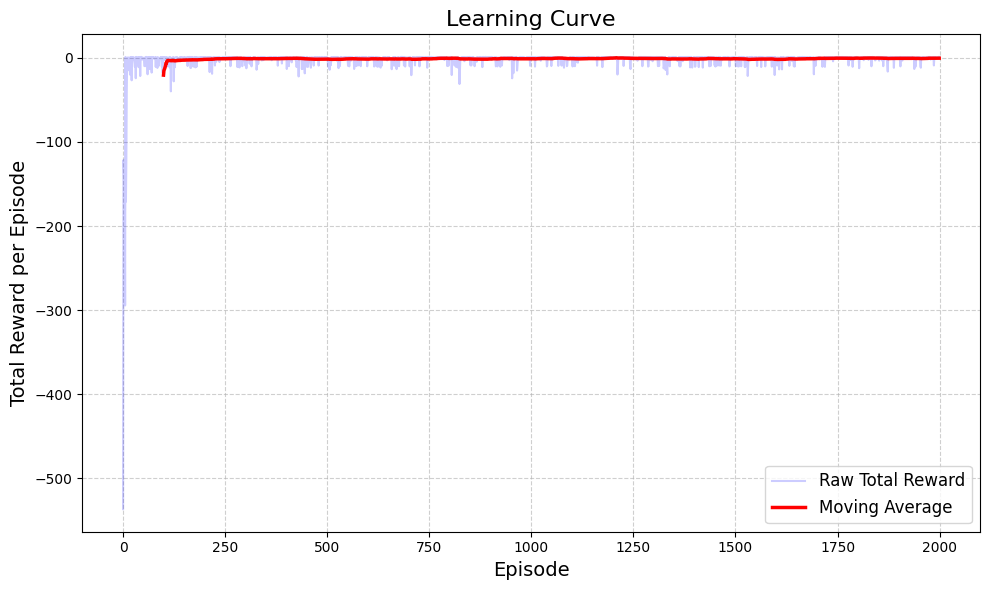

In [56]:
# 实例化环境
env = GridEnv(GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=obstacle_through)

# 训练 DQN
trained_net, target_net, learnning_curve = train_dqn(
    env, num_episodes, num_steps, state_dim, action_dim, batch_size, 
    GAMMA, EPSILON, 
    target_update_freq, capacity, obstacle_through
    )
plot_learning_curve(learnning_curve)

神经网络 Q 表提取成功！Shape: (5, 5, 5)


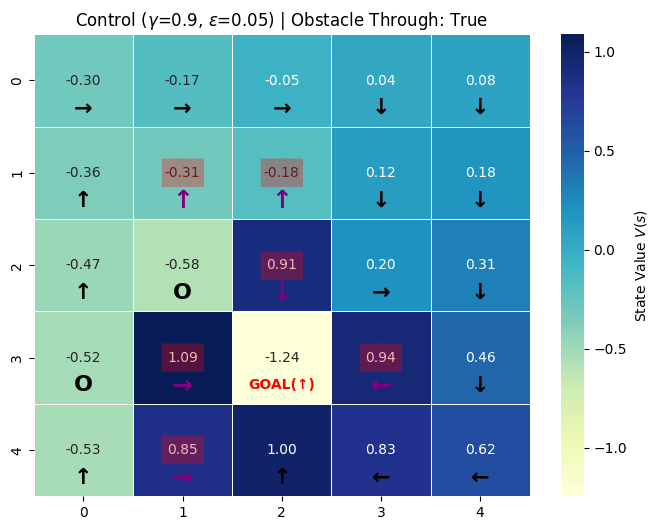

In [57]:
Q_table_DQN = extract_q_table_from_net(trained_net, env, GRID_SIZE, action_dim)
print("神经网络 Q 表提取成功！Shape:", Q_table_DQN.shape)
final_policy_dqn, final_V_dqn = extract_policy(
    GRID_SIZE, 
    OBSTACLE, 
    Q_table_DQN, 
    obstacle_through=obstacle_through
)
visualize_grid(final_V_dqn, final_policy_dqn, EPSILON, OBSTACLE, obstacle_through=obstacle_through)